# Datos abiertos de Airbnb en la ciudad de New York

Autores:
    - Santiago López Aristizábal
    - Arnoll Mauricio Florez Perez

Objetivo: Tomar un dataset público de Airbnb y crear un modelo capaz de predecir los precios de los inmuebles inscritos a la aplicación en la ciudad de New York 

Dataset: Contiene la información abierta de los alojamientos de Airbnb en la ciudad de New York. Se puede descargar en https://insideairbnb.com/get-the-data/ y el diccionario de la data en https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596 donde se tomo la última versión de listings.csv.

Resumen general del proceso realizado:
1. Obtener la data.
2. Preparación de la data:
    - Eliminación de columnas sin relevancia para el precio de los alojamientos.
    - Busquedad de duplicados.
    - Eliminación de datos pre-pandemia.
    - Reformateo de columnas.
    - Imputación de datos faltantes.
    - Creación de características con base en las comodidades de los alojamientos.
    - Creación de característica de distancia mínima a lugares turísticos.
    - Limpieza de outliers en variable objetivo e independientes.
3. Entrenamiento de modelos:
    - Elección de modelos de regresión:
        * Decision Tree
        * Random Forest
        * AdaBoosting
        * Gradient Boosting
        * Extreme Gradient Boosting
        * Regresión Lineal Múltiple
    - Creación inicial de modelos
    - Afinación de modelos.
4. Comparación de modelos
    - Resultados de R² por modelo
5. Publicación en interfaz gráfica



## 1. Librerias y configuraciones previas

In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np
import ast
import re
from collections import Counter


# Gestion de librerias
# ==============================================================================
from importlib import reload


# Matemáticas y estadísticas
# ==============================================================================
import math

# Preparación de datos
# ==============================================================================
from sklearn.neighbors import LocalOutlierFactor
from geopy.distance import geodesic

# Preprocesado y modelado
# ==============================================================================

# Creación y entrenamiento de modelos
import joblib
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Escalar Variables
from sklearn.preprocessing import StandardScaler

# Evaluacion de variables
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
# Rutas
# ==============================================================================
DATASET_PATH = 'datasets/'
MODELOS_PATH = 'modelos/'

## 2. Funciones

In [3]:
def reformat_true_false_columns(df, columns):
    for col in columns:
        df[col] = df[col].fillna('f')
        df[col] = df[col].map({'t': True, 'f': False})
    return df

def reformat_price_column(df, column):
    df[column] = df[column].str.replace('$', '').str.replace(',', '').astype(float)
    return df

def normalize_amenity(a):
    a = a.lower().strip()
    a = re.sub(r'[^a-z0-9\s]', '', a)  # eliminar símbolos y puntuación
    a = re.sub(r'\s+', ' ', a)         # colapsar espacios
    return a

def map_amenities(lst):
    mapped = set()
    for amenity in lst:
        for label, pattern in patterns.items():
            if re.search(pattern, amenity):
                mapped.add(label)
    return list(mapped)

In [4]:
# Sitios turísticos en New York City con sus coordenadas (latitud, longitud)
sitios_turisticos = {
    'statue_of_liberty': (40.6892, -74.0445),
    'central_park': (40.785091, -73.968285),
    'empire_state': (40.748817, -73.985428),
    'museo_metropolitano_de_arte_(met)': (40.7794, -73.9632),
    'time_square': (40.7580, -73.9855),
    'brooklyn_bridge': (40.7061, -73.9969),
    'vessel': (40.7532, -74.0020),
    'september_11_memorial': (40.7115, -74.0134),
    'madison_square_garden': (40.7505, -73.9934),
    'rockefeller_center': (40.7587, -73.9787),
    'museo_americano_historia_natural': (40.7813, -73.9735),
}

def distancia_minima_turistica(lat, lon):
    """Calcula la distancia mínima (en km) desde una coordenada a los sitios turísticos de NYC."""
    distancias = [
        geodesic((lat, lon), coords).km
        for coords in sitios_turisticos.values()
    ]
    return min(distancias)

In [5]:
# Funciones externas
# ==============================================================================
#sys.path.append('/home/santiago/Documentos/Especializacion/AprendizajeAutomatico1/')
#sys.path.append('..')

from utils.funciones import multiple_plot

## 3. Carga del dataset

In [6]:
#Cargar el dataset
data = pd.read_csv(DATASET_PATH +'listings.csv')

## 4. Limpieza de datos (Data Cleaning)

In [7]:
#Borrando columnas que no se utilizarán
data.drop(['listing_url','scrape_id','last_scraped','source','name','description','neighborhood_overview','picture_url','host_url','host_name','host_since','host_location','host_about','host_response_time','host_response_rate','host_acceptance_rate','host_is_superhost','host_thumbnail_url','host_picture_url','host_neighbourhood','host_listings_count','host_total_listings_count','host_verifications','host_has_profile_pic','host_identity_verified','neighbourhood','neighbourhood_cleansed','neighbourhood_group_cleansed','property_type','minimum_nights','maximum_nights','minimum_minimum_nights','maximum_minimum_nights','minimum_maximum_nights','maximum_maximum_nights','minimum_nights_avg_ntm','maximum_nights_avg_ntm','calendar_updated','has_availability','availability_30','availability_60','availability_90','availability_365','calendar_last_scraped','number_of_reviews','number_of_reviews_ltm','number_of_reviews_l30d','availability_eoy','number_of_reviews_ly','estimated_occupancy_l365d','estimated_revenue_l365d','first_review','calculated_host_listings_count','calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms','reviews_per_month','review_scores_rating','review_scores_accuracy','review_scores_cleanliness','review_scores_checkin','review_scores_communication','review_scores_location'], axis='columns', inplace=True)


Vamos a revisar si hay registros duplicados

In [8]:
datos_duplicados = data.duplicated()
print(f"Número de filas duplicadas: {datos_duplicados.sum()}")

Número de filas duplicadas: 0


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 36403 entries, 0 to 36402
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   36403 non-null  int64  
 1   host_id              36403 non-null  int64  
 2   latitude             36403 non-null  float64
 3   longitude            36403 non-null  float64
 4   room_type            36403 non-null  str    
 5   accommodates         36403 non-null  int64  
 6   bathrooms            21546 non-null  float64
 7   bathrooms_text       36276 non-null  str    
 8   bedrooms             30483 non-null  float64
 9   beds                 21495 non-null  float64
 10  amenities            36403 non-null  str    
 11  price                21279 non-null  str    
 12  last_review          25093 non-null  str    
 13  review_scores_value  25056 non-null  float64
 14  license              5466 non-null   str    
 15  instant_bookable     36403 non-null  str    
dt

La columna "license" es la que mayor cantidad de valores nulos presenta, así que vamos a analizarla

In [10]:
data['license'].unique()

<StringArray>
[                 nan, 'OSE-STRREG-0000008', 'OSE-STRREG-0001970',
 'OSE-STRREG-0001150', 'OSE-STRREG-0000108', 'OSE-STRREG-0001710',
             'Exempt', 'OSE-STRREG-0000041', 'OSE-STRREG-0000832',
 'OSE-STRREG-0001784',
 ...
 'OSE-STRREG-0003141', 'OSE-STRREG-0003088', 'OSE-STRREG-0003148',
 'OSE-STRREG-0003182', 'OSE-STRREG-0001929', 'OSE-STRREG-0003180',
 'OSE-STRREG-0002772', 'OSE-STRREG-0003191', 'OSE-STRREG-0003196',
 'OSE-STRREG-0001043']
Length: 1979, dtype: str

Vemos que la mayoría de los registros inician con "OSE-STRREG", esto hace referencia al OSE Short Term Rental Registration de la ciudad de New York. Así que revisemos los que no contenga ese string en la licencia.

In [11]:
data[~data['license'].str.upper().str.contains('OSE-STRREG', na=False)]['license'].unique()

<StringArray>
[nan, 'Exempt']
Length: 2, dtype: str

Lo que se observa de la columna "license", es que se tienen alojamientos licenciados, otros exentos y el resto sin licencia, así que se trabajará como una variable booleana, agrupando los licenciados con los exentos.

In [12]:
data['license'] = (
    data['license'].str.upper().str.contains('OSE-STRREG', na=False)
    | data['license'].str.contains('Exempt', na=False)
)


Ahora se convertira la columna "last_review" a un tipo de dato datetime para facilitar su manipulación

In [13]:
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')

Se crea una nueva columna con el año de la última reseña y el año de inscripción del host en Airbnb

In [14]:
data['year_last_review'] = data['last_review'].dt.year.astype('Int64')

# Se borra la columna con las fecha completa
data.drop(['last_review'], axis='columns', inplace=True)

Ahora analicemos esta nueva columna

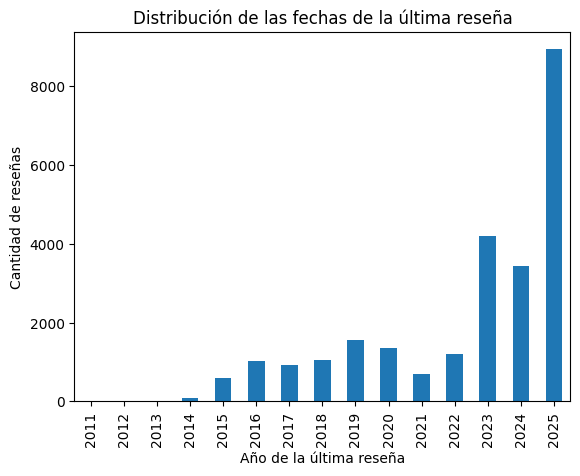

In [15]:
data['year_last_review'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de las fechas de la última reseña')
plt.xlabel('Año de la última reseña')
plt.ylabel('Cantidad de reseñas')
plt.show()

Se tienen alojamientos cuya última reseña fue hace más de 10 años y es probable que ya no estén en funcionamiento, esto puede distorsionar el análisis de la oferta de alojamientos actualmente, ya que aunque para los huéspedes no sea obligatorio realizar una reseña de los alojamientos, que no se tengan reseñas en tanto tiempo es poco probable, adicionalmente tomando en cuenta la pandemia del COVID-19 durante su apogeo en el 2020 se presento una caída drástica en las reservas por las diferentes medidas de cuarentena implementadas por los gobiernos, es decir que fue un año muy atípico para el turismo a nivel mundial y posiblemente muchos de los alojamientos tuvieron que cerrar, incluso de la tabla anterior se observa que hay una disminución en la cantidad de reseñas, por este motivo se dropearan los registros anteriores al 2022 para tener la data más reciente.

In [16]:
data.drop(data[data['year_last_review'] < 2022].index, inplace=True)

Eliminamos la columna que ya no será necesaria

In [17]:
data.drop(['year_last_review'], axis='columns', inplace=True)

Reformateamos las columnas categoricas

In [18]:
data_formatted = data.copy()
data_formatted = reformat_true_false_columns(data_formatted, ['instant_bookable'])
data_formatted = reformat_price_column(data_formatted, 'price')

Como vamos a predecir el precio de los alojamientos debemos dropear los alojamientos sin precio

In [19]:
# Dropear registros sin precio
data_formatted.dropna(subset=['price'], inplace=True)

In [20]:
# Reorganizamos el dataframe para que la variable objetivo esté en la primera columna
cols = data_formatted.columns.tolist()
cols.insert(0, cols.pop(cols.index('price')))
data_formatted = data_formatted[cols]

También eliminamos los registros que no tienen puntuaciones en las reseñas 

In [21]:
data_formatted = data_formatted[data_formatted['review_scores_value'].notna()]
data_formatted.reset_index(drop=True, inplace=True)

In [22]:
data_formatted.info()

<class 'pandas.DataFrame'>
RangeIndex: 14019 entries, 0 to 14018
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                14019 non-null  float64
 1   id                   14019 non-null  int64  
 2   host_id              14019 non-null  int64  
 3   latitude             14019 non-null  float64
 4   longitude            14019 non-null  float64
 5   room_type            14019 non-null  str    
 6   accommodates         14019 non-null  int64  
 7   bathrooms            14015 non-null  float64
 8   bathrooms_text       14008 non-null  str    
 9   bedrooms             13985 non-null  float64
 10  beds                 13990 non-null  float64
 11  amenities            14019 non-null  str    
 12  review_scores_value  14019 non-null  float64
 13  license              14019 non-null  bool   
 14  instant_bookable     14019 non-null  bool   
dtypes: bool(2), float64(7), int64(3), str(3)
memory

Segun esto tenemos varios registros que no tienen baños, ni camas, ni habitaciones.

Evaluemos los registros a los que le falta la cantidad de baños

In [23]:
data_formatted[data_formatted['bathrooms'].isnull()][['bathrooms_text', 'bathrooms']].head()

,bathrooms_text,bathrooms
166,NaN,NaN
11144,NaN,NaN
13343,NaN,NaN
13893,NaN,NaN


Como no podemos asignarles el valor desde el 'bathrooms_text', los dropeamos y también esa columna

In [24]:
data_formatted = data_formatted[data_formatted['bathrooms'].notna()]
data_formatted.drop(columns=['bathrooms_text'], inplace=True)
data_formatted.reset_index(drop=True, inplace=True)

Ahora revisemos que sucede con la columna 'beds'

<Axes: xlabel='beds'>

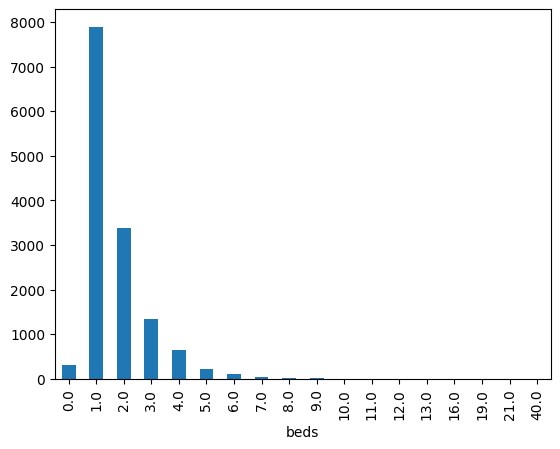

In [25]:
data_formatted['beds'].value_counts().sort_index().plot(kind='bar')

In [26]:
# Imputar valores faltantes de 'beds' con la moda según 'room_type'
data_formatted['beds'] = data_formatted['beds'].fillna(
    data_formatted.groupby('room_type')['beds']
    .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [27]:
# Reemplazar valores 0 en 'beds' con el valor entero de la división entre 'accommodates' y 2
data_formatted['beds'] = data_formatted.apply(
    lambda row: max(1, row['accommodates'] // 2) if row['beds'] == 0 else row['beds'], axis=1
)

Ahora revisemos que sucede con la columna 'bedrooms'

<Axes: xlabel='bedrooms'>

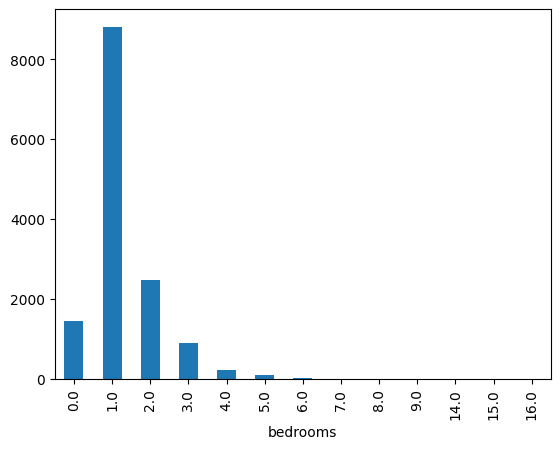

In [28]:
data_formatted['bedrooms'].value_counts().sort_index().plot(kind='bar')

In [29]:
# Imputar valores faltantes de 'bedrooms' con la moda según 'room_type'
data_formatted['bedrooms'] = data_formatted['bedrooms'].fillna(
    data_formatted.groupby('room_type')['bedrooms']
    .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

In [30]:
# Como no tenemos registros duplicados y ya se realizó la limpieza del dataset podemos proceder a dropear las columnas de id y host_id
data_formatted.drop(['id','host_id'], axis='columns', inplace=True)

In [31]:
data_formatted.info()

<class 'pandas.DataFrame'>
RangeIndex: 14015 entries, 0 to 14014
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                14015 non-null  float64
 1   latitude             14015 non-null  float64
 2   longitude            14015 non-null  float64
 3   room_type            14015 non-null  str    
 4   accommodates         14015 non-null  int64  
 5   bathrooms            14015 non-null  float64
 6   bedrooms             14015 non-null  float64
 7   beds                 14015 non-null  float64
 8   amenities            14015 non-null  str    
 9   review_scores_value  14015 non-null  float64
 10  license              14015 non-null  bool   
 11  instant_bookable     14015 non-null  bool   
dtypes: bool(2), float64(7), int64(1), str(2)
memory usage: 1.1 MB


Ahora vamos a procesar las comodidades de los alojamientos

In [32]:
# Normalizamos las comodidades, quitamos símbolos y dejamos todo en minusculas
data = data_formatted.copy()
data['amenities'] = data['amenities'].apply(lambda x: ast.literal_eval(x))
data['amenities'] = data['amenities'].apply(lambda lst: [normalize_amenity(x) for x in lst])
data['amenities']

0        [ethernet connection, self checkin, hot water,...
1        [microwave, hot water, hair dryer, washer, ext...
2        [clothing storage, hot water, hair dryer, extr...
3        [outdoor furniture, hot water kettle, microwav...
4        [blender, free washer in unit, ethernet connec...
                               ...                        
14010    [hot water kettle, microwave, stainless steel ...
14011    [free washer in unit, hot water kettle, microw...
14012    [hot water kettle, microwave, clothing storage...
14013    [hot water kettle, microwave, clothing storage...
14014                   [kitchenette, ethernet connection]
Name: amenities, Length: 14015, dtype: object

Se definen algunas de las palabras más frecuentes que se van a encontrar en las comodidades de los alojamientos y se agrupan de la siguiente forma

In [33]:
patterns_initial = {
    'essentials' : r'wifi|internet|heater|heating|radiator|furnace|air.?conditioning|ac\b|hot water|kitchen|stove|oven|microwave|refrigerator|cook|fridge|dishwasher|coffee maker|toaster|fire alarm|smoke alarm|fire extinguisher|carbon monoxide',
    'luxurious' : r'pool|swim|gym|fitness|exercise equipment|sound system|stereo|speaker',
    'tv': r'\btv\b|hdtv|netflix|roku|smart tv|flat.?screen|cable|apple tv|chromecast|prime video',
    'parking': r'parking|garage',
    'washer': r'washer|laundry|washing machine',
    'dryer': r'\bdryer\b(?! hair)',
    'hair_dryer': r'hair dryer',
    'cleaning_products': r'cleaning product|detergent|soap|shampoo|conditioner|body wash',
}

In [34]:
patterns = {
    'kitchen': r'kitchen|stove|oven|microwave|refrigerator|fridge|dishwasher|coffee maker|toaster|cookware|kettle',
    'climate': r'heater|heating|radiator|furnace|air.?conditioning|\bac\b|fan',
    'wifi': r'wifi|internet|ethernet',
    'luxurious' : r'pool|swim|gym|fitness|exercise equipment|sound system|stereo|speaker|hot tub|jacuzzi|spa|sauna|home theater|game room|piano',
    'tv': r'\btv\b|hdtv|smart tv|flat.?screen|netflix|roku|apple tv|chromecast|prime video|disney|cable',
    'parking': r'parking|garage|carport|free parking',
    'washer': r'washer|laundry|washing machine',
    'dryer': r'\bdryer\b(?! hair)',
    'hair_dryer': r'hair dryer',
    'cleaning_products': r'cleaning product|detergent|soap|shampoo|conditioner|body wash|towels|linens|bed sheets',
    'workspace': r'workspace|desk|office|laptop friendly|work desk',
    'balcony_view': r'balcony|patio|terrace|deck|garden|yard|view|sea view|mountain view|city view',
    'family': r'crib|high chair|baby bath|children|kids|toys|books for children',
    'pet_friendly': r'pet|pets allowed',
    'security': r'lock|safe|security camera|alarm system',
    'accessibility': r'wheelchair|accessible|elevator|lift',
    'outdoor': r'bbq|barbecue|grill|fire pit|outdoor furniture',
    'entertainment': r'game|console|xbox|playstation|board games',
}

In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14015 entries, 0 to 14014
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                14015 non-null  float64
 1   latitude             14015 non-null  float64
 2   longitude            14015 non-null  float64
 3   room_type            14015 non-null  str    
 4   accommodates         14015 non-null  int64  
 5   bathrooms            14015 non-null  float64
 6   bedrooms             14015 non-null  float64
 7   beds                 14015 non-null  float64
 8   amenities            14015 non-null  object 
 9   review_scores_value  14015 non-null  float64
 10  license              14015 non-null  bool   
 11  instant_bookable     14015 non-null  bool   
dtypes: bool(2), float64(7), int64(1), object(1), str(1)
memory usage: 1.1+ MB


In [36]:
# Se agrupan las amenidades
data['amenities_grouped'] = data['amenities'].apply(map_amenities)

# Unir todas las listas en una sola
amenities_flat = [amenity for sublist in data['amenities_grouped'] for amenity in sublist]

# Contar frecuencia
counter = Counter(amenities_flat)

print("Frecuencia de amenidades agrupadas:")
for amenity, freq in counter.most_common():
    print(f"{amenity}: {freq}")

Frecuencia de amenidades agrupadas:
wifi: 13912
climate: 13906
kitchen: 13646
cleaning_products: 12142
dryer: 11767
tv: 11713
hair_dryer: 10777
luxurious: 9850
security: 9795
parking: 9222
workspace: 8933
washer: 7133
balcony_view: 4635
pet_friendly: 3573
accessibility: 2913
outdoor: 2619
family: 2613
entertainment: 1355


In [37]:
# Se crea una columna dummy por cada amenidad agrupada
for a,_ in counter.items():
    data[f'amenity_{a}'] = data['amenities_grouped'].apply(lambda x: a in x) # Devuelve True o False

También se creará una nueva variable con la cantidad de amenidades

In [38]:
data["amenities_count"] = data["amenities"].apply(len)

In [39]:
# Eliminar las columnas que más del 90% de los registros tienen esa amenidad y se pueden considerar esenciales
data.drop(['amenity_wifi', 'amenity_climate', 'amenity_kitchen'], axis='columns', inplace=True)

In [40]:
# Eliminar las columnas auxiliares o que ya no se utilizarán y la de esenciales ya que practicamente todos los registros tienen esa amenidad
#data.drop(['amenities', 'amenities_grouped', 'amenity_essentials'], axis='columns', inplace=True)

Vamos a crear una nueva variable que nos indique la distancia mínima en kilometros a alguno de los sitios turisticos de New York City, ya que esto generalmente resulta relevante a la hora de definir los precios para un alojamiento

In [41]:
data["distance_min"] = data.apply(lambda row: distancia_minima_turistica(row["latitude"], row["longitude"]), axis=1)

## 5. Visualización de datos

### Variable de salida

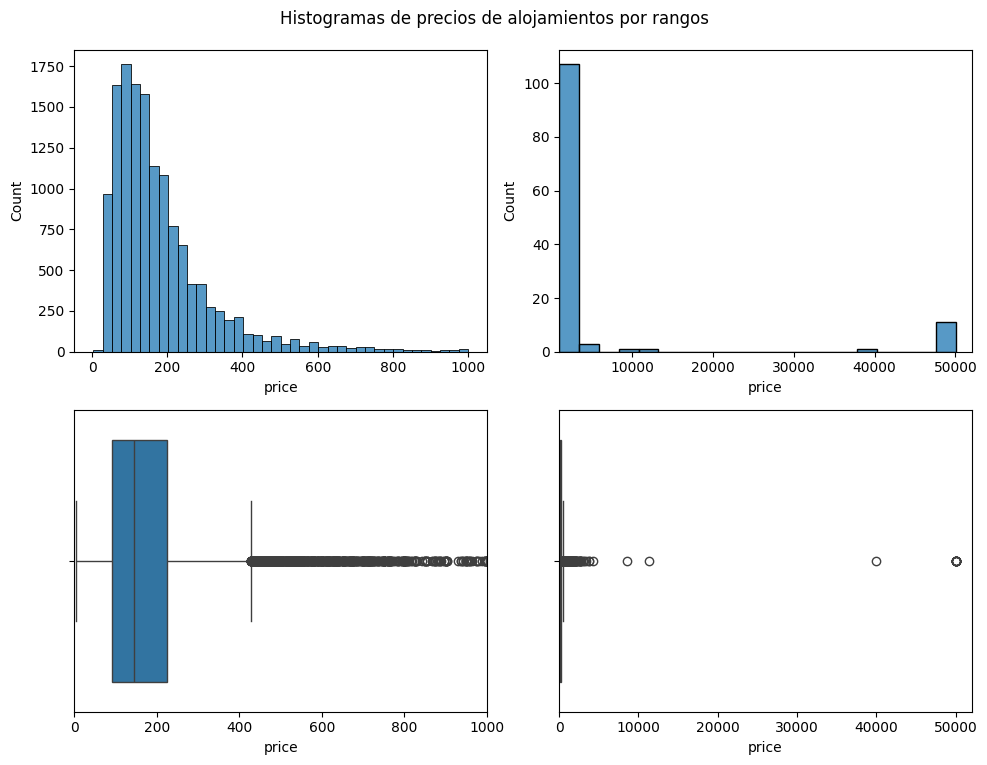

In [42]:
# Histogramas y boxplots de precios por rangos
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axs = axs.flatten()

sns.histplot(data[data['price'] <= 1000]['price'], bins=40, ax=axs[0])

sns.histplot(data[data['price'] > 1000]['price'], bins=20, ax=axs[1])
axs[1].set_xlim(1000, 52000)  # limitar escala para ver mejor

sns.boxplot(x=data['price'], ax=axs[2])
axs[2].set_xlim(0, 1000)  # limitar escala para ver mejor

sns.boxplot(x=data['price'], ax=axs[3])
axs[3].set_xlim(0, 52000)  # limitar escala para ver mejor

fig.suptitle('Histogramas de precios de alojamientos por rangos')
plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Ajustar el rectangulo para dejar espacio al suptitle
plt.show()

Calculo de valores atípicos

In [43]:
#Calculo de Q1 t Q3
Q1 = np.percentile(data['price'], 25, method = 'midpoint')
Q3 = np.percentile(data['price'], 75, method = 'midpoint')

#Cálculo del rango intercuartil
IQR = Q3 - Q1

#Cálculo de valor mínimo y máximo para los valores atípicos
VAInf = Q1 - 1.5*IQR
VASup = Q3 + 1.5*IQR

print(f'Valor atípico leve inferior:{VAInf}')
print(f'Valor atípico leve superior:{VASup}')

Valor atípico leve inferior:-112.5
Valor atípico leve superior:427.5


In [44]:
data[data['price']>VASup].shape

(902, 30)

In [45]:
# Se eliminan los valores atípicos de la variable objetivo
data = data.drop(data[data['price']>VASup].index)

#Reiniciar el indice
data.reset_index(drop=True, inplace=True)

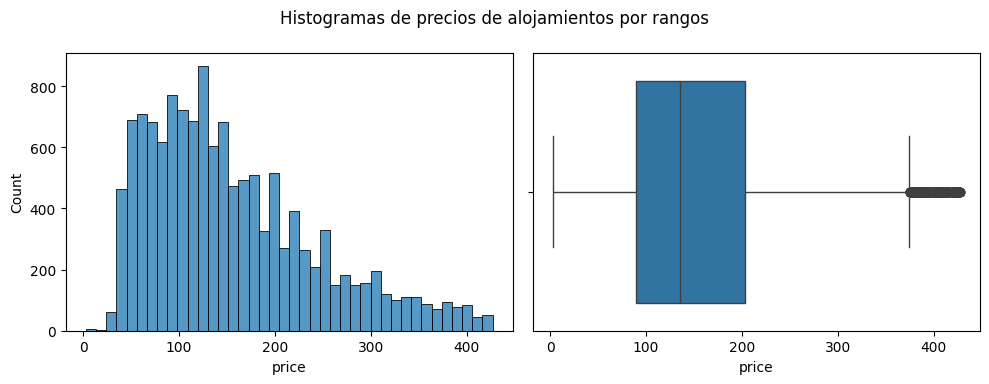

In [46]:
# Histogramas y boxplots de precios por rangos
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axs = axs.flatten()

sns.histplot(data['price'], bins=40, ax=axs[0])

sns.boxplot(x=data['price'], ax=axs[1])

fig.suptitle('Histogramas de precios de alojamientos por rangos')
plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Ajustar el rectangulo para dejar espacio al suptitle
plt.show()

### Variables entrada

In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13113 entries, 0 to 13112
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      13113 non-null  float64
 1   latitude                   13113 non-null  float64
 2   longitude                  13113 non-null  float64
 3   room_type                  13113 non-null  str    
 4   accommodates               13113 non-null  int64  
 5   bathrooms                  13113 non-null  float64
 6   bedrooms                   13113 non-null  float64
 7   beds                       13113 non-null  float64
 8   amenities                  13113 non-null  object 
 9   review_scores_value        13113 non-null  float64
 10  license                    13113 non-null  bool   
 11  instant_bookable           13113 non-null  bool   
 12  amenities_grouped          13113 non-null  object 
 13  amenity_tv                 13113 non-null  bool   
 14  a

In [48]:
#Lista de variables categóricas
catCols = data.select_dtypes(include = ["str", 'bool']).columns.tolist()

#Lista de variables numéricas
numCols = data.select_dtypes(include = ['float64','int64']).columns.tolist()

# Se dropean la variable objetivo
numCols.remove('price')

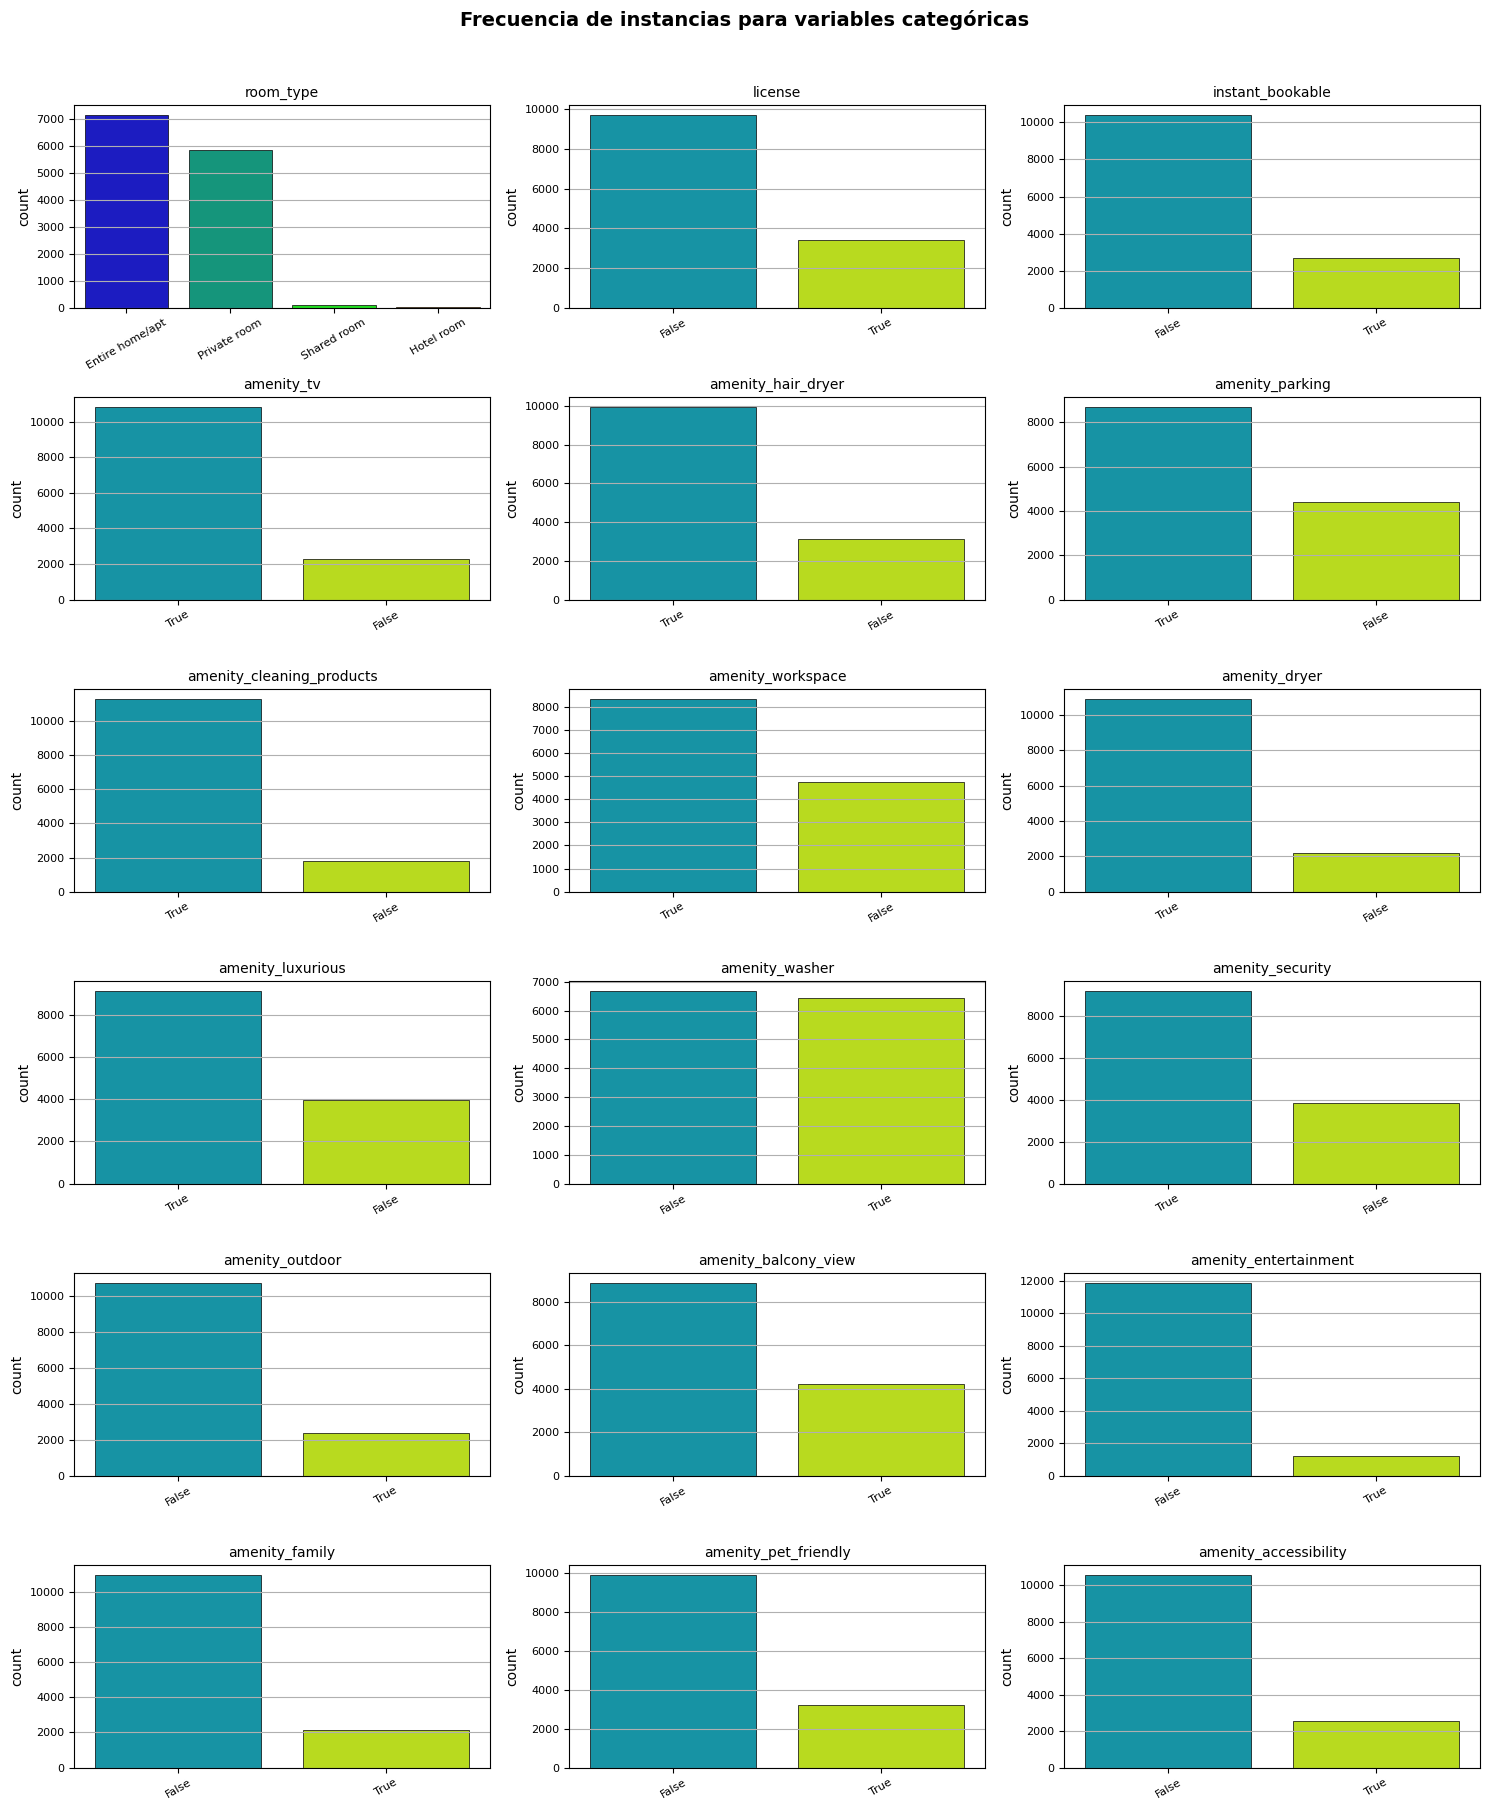

In [49]:
#Visualización de frecuencia de instancias para variables categóricas
multiple_plot(3, data , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

Para 'room_type' hay una poca cantidad de shared_room y hotel_room por lo que se dropearan estos registros y la variable se transformará en una booleana para identificar si es un apartamento completo o habitación privada

In [50]:
# Dropear del dataframe los 'Shared room' y 'Hotel room'
data = data[~data['room_type'].isin(['Shared room', 'Hotel room'])]
data.reset_index(drop=True, inplace=True)

In [51]:
# Renombrar 'room_type' a 'is_entire_home' como booleana
data['is_entire_home'] = data['room_type'].map({'Entire home/apt': True, 'Private room': False})

# Dropear la columna original
data.drop(['room_type'], axis='columns', inplace=True)

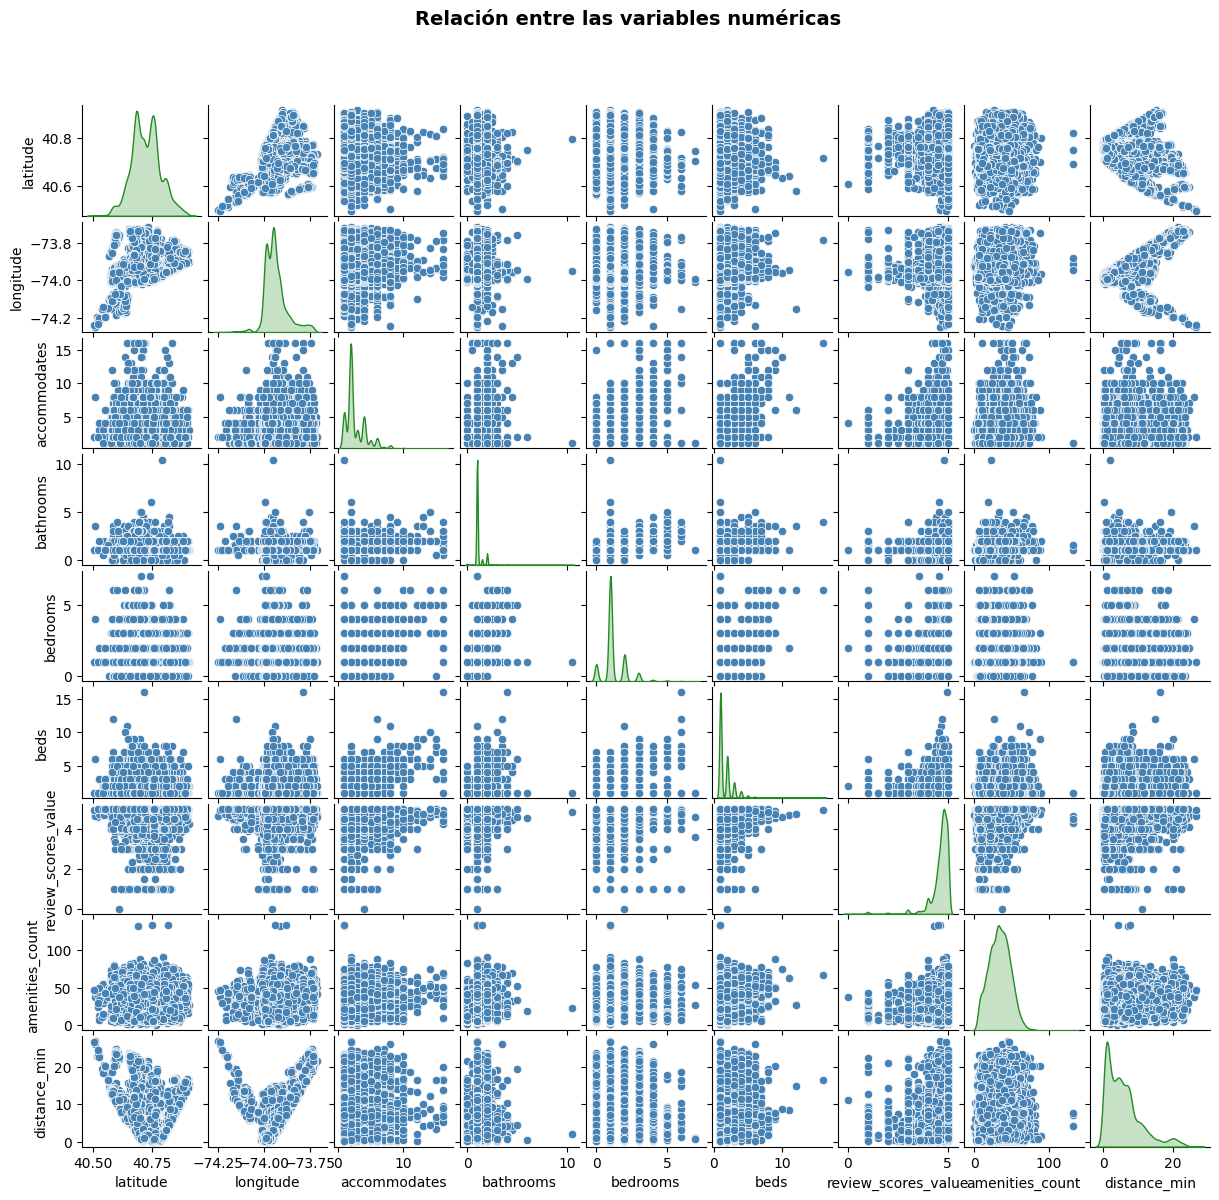

In [52]:
# Visualización de variables numéricas relacionada al host
multiple_plot(1, data , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

Como observamos en las diferentes gráficas tenemos algunos outliers y una buena dispersión entre los datos. 

La relación entre las coordenadas y la distancia mínima como era de esperarse presentan un patron.

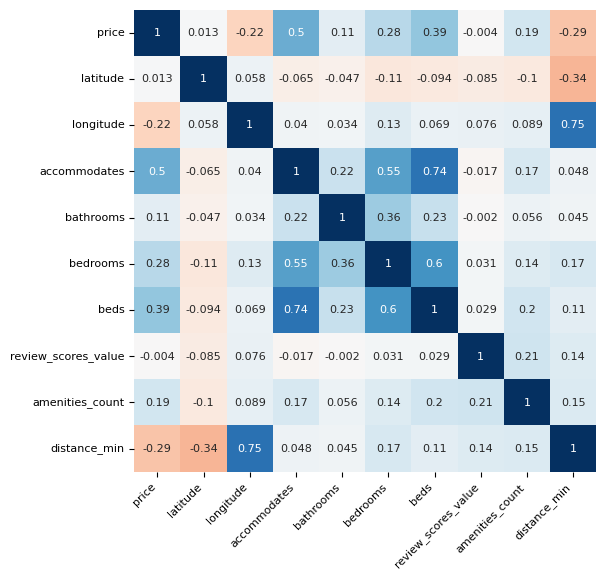

In [53]:
# Calculamos la correlación entre las variables númericas y el precio
matrizCorr = data[['price']+numCols].corr()
# Mapa de calor (Heatmap) de la matriz de correlaciones

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

sns.heatmap(
    matrizCorr,
    annot     = True,
    cbar      = False,
    annot_kws = {"size": 8},
    vmin      = -1,
    vmax      = 1,
    center    = 0,
    cmap      = 'RdBu',
    square    = True,
    ax        = ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation = 45,
    horizontalalignment = 'right',
)


ax.tick_params(labelsize = 8)

## 6. Preparación de los datos

#### Valores atípicos para las variables de entrada

In [54]:
# Utilización de LocalOutlierFactor con 6 vecinos para identificar valores atípicos en las variables de entrada

# Crear un objeto LocalOutlierFactor con n_neighbors=6
lof = LocalOutlierFactor(n_neighbors=6, contamination=0.1)

# Identificar los valores atípicos por medio de lof
y_pred = lof.fit_predict(data[numCols])

# Identificar los índices de los valores atípicos
outliers = y_pred == -1

print('Indices de valores atípicos: ', data[outliers].index.tolist())
print(len(data[outliers]))

Indices de valores atípicos:  [0, 1, 2, 4, 27, 31, 35, 58, 66, 67, 69, 78, 95, 100, 101, 108, 112, 132, 137, 143, 148, 150, 159, 167, 188, 192, 195, 204, 208, 216, 218, 219, 235, 239, 257, 268, 280, 312, 335, 341, 346, 351, 366, 382, 403, 417, 424, 427, 431, 445, 447, 448, 456, 458, 462, 463, 471, 476, 486, 492, 495, 527, 535, 543, 558, 563, 570, 576, 583, 593, 605, 612, 616, 625, 633, 637, 647, 650, 652, 679, 687, 689, 694, 702, 703, 707, 715, 723, 726, 731, 737, 745, 748, 760, 770, 784, 793, 800, 801, 819, 820, 823, 845, 870, 871, 877, 880, 881, 890, 902, 907, 909, 911, 913, 921, 930, 947, 958, 960, 966, 972, 1007, 1029, 1032, 1045, 1073, 1085, 1086, 1089, 1115, 1122, 1125, 1142, 1171, 1172, 1179, 1190, 1204, 1221, 1223, 1227, 1232, 1239, 1250, 1252, 1265, 1277, 1279, 1299, 1310, 1317, 1319, 1350, 1351, 1361, 1363, 1382, 1383, 1386, 1397, 1400, 1417, 1418, 1420, 1433, 1434, 1451, 1454, 1463, 1475, 1480, 1484, 1494, 1498, 1516, 1524, 1549, 1552, 1577, 1580, 1583, 1592, 1606, 1608, 162

In [55]:
# Creamos un nuevo dataframe sin outliers
data_sin_outliers = data[~outliers]
data_sin_outliers.reset_index(drop=True, inplace=True)

## 7. Exportar el dataset

In [56]:
# Exportamos el dataframe a un archivo CSV
data_sin_outliers.to_csv(DATASET_PATH + 'Airbnb_NY_cleaned.csv', index=False)

## 8. Preparación de la data para el modelo

In [57]:
data_cleaned = pd.read_csv(DATASET_PATH + 'Airbnb_NY_cleaned.csv')

### Preparación de variable objetivo
Se aplica una transformación logaritmica al precio (variable objetivo). Esto reduce la influencia de outliers y mejora el ajuste para relaciones multiplicativas (típicas en precios)

In [58]:
data_cleaned['price'] = np.log(data_cleaned['price'])

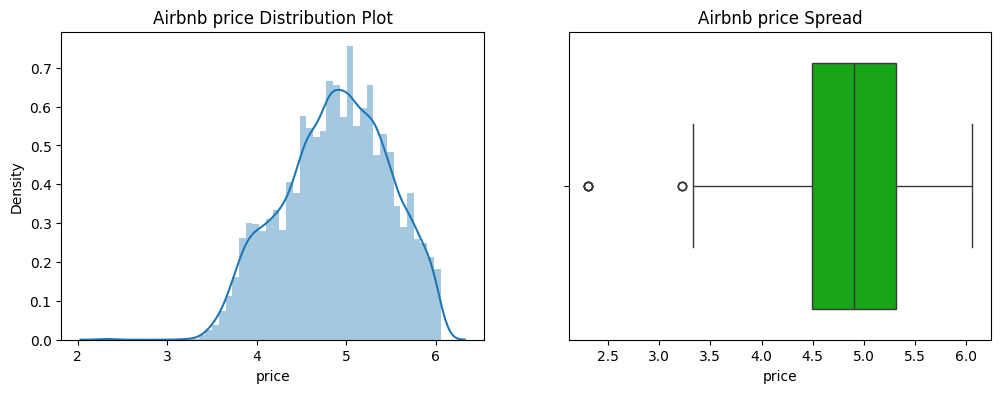

In [59]:
data = data_cleaned.copy()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title('Airbnb price Distribution Plot')
sns.distplot(data.price)

plt.subplot(1,2,2)
plt.title('Airbnb price Spread')
sns.boxplot(x=data.price, palette='nipy_spectral')

plt.show()

In [60]:
#Se establece las variables de entrada 'X' y la variable de salida 'y'

X = data.drop(columns = ["price","amenities","amenities_grouped"])
y = data['price']

Obtenemos los datos de entrenamiento y prueba para los modelos iniciales

In [61]:
#En este caso, el 80% de los datos se utilizarán para entrenar el modelo.
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

#Escalar las variables de entrada
num_vars = X.select_dtypes(include=['number']).columns.tolist()
print("Columnas Numéricas:{}".format(num_vars))

scaler = StandardScaler()

X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars]  = scaler.transform(X_test[num_vars])

Columnas Numéricas:['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'review_scores_value', 'amenities_count', 'distance_min']


Obtenemos los datos completos para los tunnings de los modelos y el escalado en producción

In [62]:
# Nuevamente se asigna a 'X_Completo' y 'y_Completo' los datos entrada y salida respectivamente
X_Completo = X
y_Completo = y

# Se escalan los datos numéricos de entrada
X_Completo[num_vars] = scaler.fit_transform(X_Completo[num_vars])

# Se guarda el scaler
#joblib.dump(scaler, '../modelos/scaler/StandarScalerFull_Airbnb_V1.pkl')

## 9. Validación de modelos

In [63]:
# Diccionario para almacenar los resultados de los modelos
resultados_modelos = {}

### 9.1 MLP

In [64]:
model_mlp = Sequential([
    Dense(32, activation="relu", input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(1)
])

model_mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [65]:
history_mlp = model_mlp.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/50
249/249 - 1s - 4ms/step - loss: 4.0712 - mae: 1.5205 - val_loss: 0.5222 - val_mae: 0.5603
Epoch 2/50
249/249 - 0s - 622us/step - loss: 0.9515 - mae: 0.7761 - val_loss: 0.3700 - val_mae: 0.4768
Epoch 3/50
249/249 - 0s - 623us/step - loss: 0.7085 - mae: 0.6674 - val_loss: 0.4067 - val_mae: 0.5153
Epoch 4/50
249/249 - 0s - 603us/step - loss: 0.5597 - mae: 0.5901 - val_loss: 0.3442 - val_mae: 0.4699
Epoch 5/50
249/249 - 0s - 629us/step - loss: 0.4341 - mae: 0.5195 - val_loss: 0.3195 - val_mae: 0.4531
Epoch 6/50
249/249 - 0s - 602us/step - loss: 0.3436 - mae: 0.4588 - val_loss: 0.3245 - val_mae: 0.4630
Epoch 7/50
249/249 - 0s - 641us/step - loss: 0.2939 - mae: 0.4279 - val_loss: 0.3247 - val_mae: 0.4637
Epoch 8/50
249/249 - 0s - 697us/step - loss: 0.2504 - mae: 0.3926 - val_loss: 0.2361 - val_mae: 0.3856
Epoch 9/50
249/249 - 0s - 617us/step - loss: 0.2175 - mae: 0.3650 - val_loss: 0.2623 - val_mae: 0.4139
Epoch 10/50
249/249 - 0s - 598us/step - loss: 0.1929 - mae: 0.3445 - val_lo

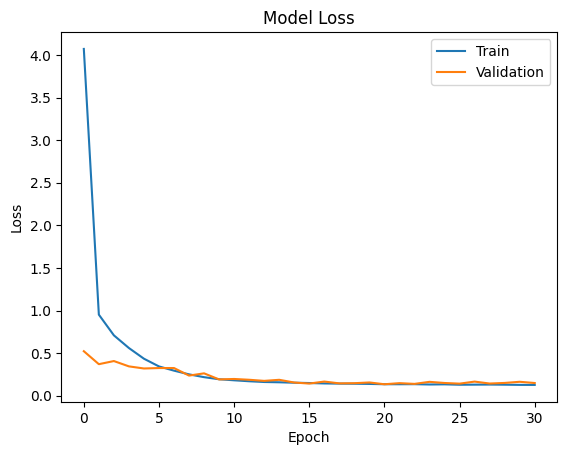

In [66]:
plt.plot(history_mlp.history["loss"])
plt.plot(history_mlp.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [67]:
test_loss, test_mae = model_mlp.evaluate(
    X_test,
    y_test
)

print("Test MAE:", test_mae)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.1453 - mae: 0.2983
Test MAE: 0.2982753813266754


In [68]:
y_pred_log = model_mlp.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_real = np.expm1(y_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step


In [69]:
r2 = r2_score(y_real, y_pred)

print("R²:", r2)

R²: 0.4490778508690316


### 9.2 Embeddings

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3458 - mae: 0.3400 - val_loss: 0.0175 - val_mae: 0.1033
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0145 - mae: 0.0947 - val_loss: 0.0124 - val_mae: 0.0869
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0111 - mae: 0.0832 - val_loss: 0.0104 - val_mae: 0.0799
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0095 - mae: 0.0771 - val_loss: 0.0093 - val_mae: 0.0763
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0086 - mae: 0.0738 - val_loss: 0.0089 - val_mae: 0.0743
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0082 - mae: 0.0718 - val_loss: 0.0088 - val_mae: 0.0746
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0078 - mae: 0.0700 - val_loss: 0.0086 - val_mae: 0.0737
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0074 - mae: 0.0685 - val_loss: 0.0086 - val_mae: 0.0736
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

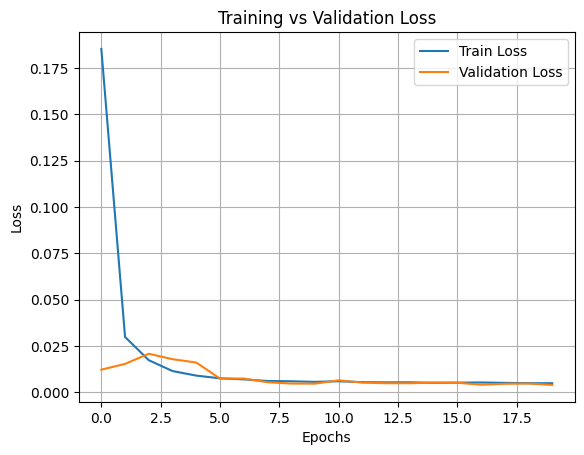

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step
MAE: 0.31
RMSE: 0.40
R2: 0.534
                   MAE      RMSE        R2  \
NN_embeddings  0.30897  0.397377  0.534207   

                                                         history  
NN_embeddings  {'loss': [0.18524491786956787, 0.0298760589212...  


In [ ]:
# ============================================
# 📦 Imports
# ============================================
import pandas as pd
import numpy as np
import ast
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, GlobalAveragePooling1D,
    Dense, Dropout, Concatenate
)
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================
# 📥 Cargar datos
# ============================================
df = data_cleaned.copy()

# ============================================
# 🧹 Procesar amenities
# ============================================
df['amenities_list'] = df['amenities'].apply(ast.literal_eval)

# Crear vocabulario
all_amenities = [item for sublist in df['amenities_list'] for item in sublist]
vocab = {k: i+1 for i, (k, _) in enumerate(Counter(all_amenities).items())}

# Codificar
def encode_amenities(lst):
    return [vocab[item] for item in lst if item in vocab]

df['amenities_encoded'] = df['amenities_list'].apply(encode_amenities)

# Padding
max_len = 20
X_amenities = pad_sequences(df['amenities_encoded'], maxlen=max_len, padding='post')

# ============================================
# 🔢 Variables numéricas
# ============================================
num_cols = [
    'latitude','longitude','accommodates','bathrooms','bedrooms',
    'beds','review_scores_value','amenities_count','distance_min'
]

X_num = df[num_cols].values

# 🔥 (recomendado) usar log del precio
y = np.log1p(df['price'].values)

# Escalar
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# ============================================
# ✂️ Train / Test split
# ============================================
X_amen_train, X_amen_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_amenities, X_num_scaled, y, test_size=0.2, random_state=42
)

# ============================================
# 🧠 1. PREENTRENAMIENTO (solo amenities)
# ============================================
vocab_size = len(vocab) + 1
embedding_dim = 16

input_amen = Input(shape=(max_len,))
x = Embedding(vocab_size, embedding_dim)(input_amen)
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation='relu')(x)
output = Dense(1)(x)

model_pretrain = Model(input_amen, output)

model_pretrain.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_pretrain.fit(
    X_amen_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Guardar embeddings
embedding_weights = model_pretrain.layers[1].get_weights()

# ============================================
# 🧠 2. MODELO FINAL (transfer learning)
# ============================================

# Input amenities
input_amen = Input(shape=(max_len,))
emb = Embedding(
    vocab_size,
    embedding_dim,
    weights=embedding_weights,
    trainable=False
)(input_amen)

emb = GlobalAveragePooling1D()(emb)

# Input numérico
input_num = Input(shape=(X_num_train.shape[1],))

# Combinar
x = Concatenate()([emb, input_num])

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)

output = Dense(1)(x)

model_final = Model([input_amen, input_num], output)

model_final.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# ============================================
# 🚀 Entrenamiento final
# ============================================
history = model_final.fit(
    [X_amen_train, X_num_train],
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ============================================
# 🔓 Fine-tuning
# ============================================
model_final.layers[1].trainable = True

model_final.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_final.fit(
    [X_amen_train, X_num_train],
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ============================================
# 📉 Gráfica de loss
# ============================================
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

# ============================================
# 📊 Evaluación
# ============================================
y_pred_log = model_final.predict([X_amen_test, X_num_test])

# volver a escala original
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

# ============================================
# 💾 Guardar resultados
# ============================================
if 'resultados_modelos' not in globals():
    resultados_modelos = {}

resultados_modelos['NN_embeddings'] = {
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}

# ============================================
# 📊 Comparación rápida
# ============================================
print(pd.DataFrame(resultados_modelos).T)

In [76]:
resultados_modelos


{'NN_embeddings': {'MAE': 0.30897020467719305,
  'RMSE': np.float64(0.39737736358990866),
  'R2': 0.5342065922135733,
  'history': {'loss': [0.18524491786956787,
    0.02987605892121792,
    0.017359448596835136,
    0.011509348638355732,
    0.009047891944646835,
    0.00759112136438489,
    0.007021553814411163,
    0.006147695705294609,
    0.00599026819691062,
    0.005677703768014908,
    0.005997279193252325,
    0.005504141096025705,
    0.005422566551715136,
    0.005431391764432192,
    0.005183369852602482,
    0.005250896327197552,
    0.0053438772447407246,
    0.005129094235599041,
    0.004966854117810726,
    0.004929781891405582],
   'mae': [0.2897932231426239,
    0.13399159908294678,
    0.10189095884561539,
    0.08387378603219986,
    0.07432657480239868,
    0.06859531253576279,
    0.06512083858251572,
    0.0615101233124733,
    0.06102432310581207,
    0.05923905223608017,
    0.06100187450647354,
    0.05800190940499306,
    0.057823359966278076,
    0.05760527